<a href="https://colab.research.google.com/github/LuisManuelCatzoliSoriano/Simulacion-I/blob/main/ETIBASA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TIBASA

La empresa TIBASA (Fabricante de tinas de baño) tiene asignado un camión especial para el transporte de tinas terminadas. Dicho camión transporta diariamente $5$ tinas. El peso de cada tina sigue la distribución triangular de la imagen anexa.  

Si la capacidad del camión es de 1 tonelada, ¿cuál es la probabilidad de que el peso de las tinas exceda la capacidad del camión?

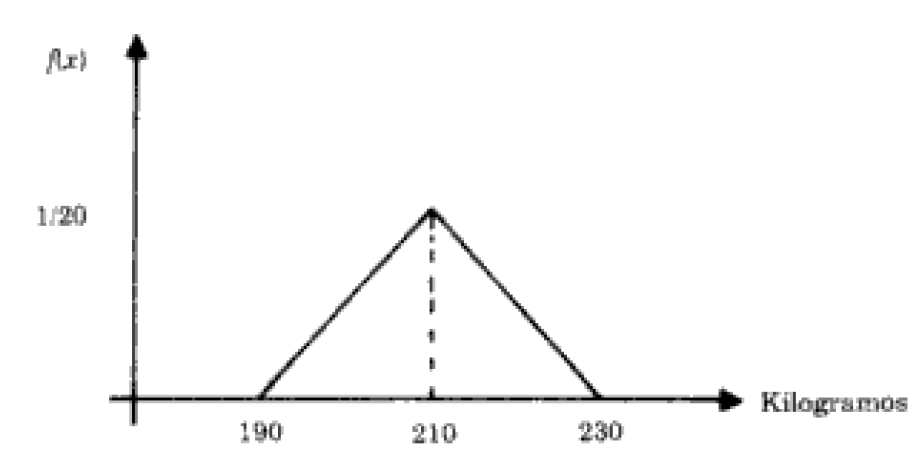

Primero la solución analítica:

Sea $X$ el peso (en kg) de una tina, con distribución triangular con parámetros:

$$
a = 190, \quad b = 230, \quad c = 210
$$

1. Media y varianza

Para una distribución triangular:

$$
\mu = \frac{a + b + c}{3}, \quad
\sigma^2 = \frac{a^2 + b^2 + c^2 - ab - ac - bc}{18}
$$

Sustituyo:

$$
\mu = \frac{190 + 230 + 210}{3} = 210
$$

$$
\sigma^2 = \frac{190^2 + 230^2 + 210^2 - (190\cdot230 + 190\cdot210 + 230\cdot210)}{18}
$$

$$
\sigma^2 = \frac{36100 + 52900 + 44100 - (43700 + 39900 + 48300)}{18}
$$

$$
\sigma^2 = \frac{133100 - 131900}{18} = \frac{1200}{18} = 66.67
$$

$$
\sigma = \sqrt{66.67} \approx 8.165
$$

2. Suma de 5 tinas

Sea $S = X_1 + X_2 + X_3 + X_4 + X_5$, con $X_i$ independientes.

$$
\mu_S = 5\mu = 5(210) = 1050
$$

$$
\sigma_S = \sqrt{5\sigma^2} = \sqrt{5(66.67)} \approx 18.26
$$

3. Aproximación normal

Por el Teorema Central del Límite:

$$
S \sim N(1050, 18.26)
$$

Quiero calcular:

$$
P(S > 1000)
$$

Al estandar:

$$
Z = \frac{1000 - 1050}{18.26} \approx -2.74
$$

Entonces:

$$
P(S > 1000) = P(Z > -2.74)
$$

$$
P(Z > -2.74) \approx 0.997
$$

Resultado final

$$
\boxed{P(S > 1000) \approx 0.997}
$$


Ahora la solución por simulación:

Paso 1:

Variables: Peso de las tinas

$$x_1, x_2, x_3, x_4, x_5$$

$x_{i}\sim$ triangular $(a=190kg, b=230kg, c=210kg)$.

Necesitamos la suma:

$s=x_1+x_2+x_3+x_4+x_5$

Existe un teorema que dice que la suma de variables que sin importar la distribución de la que vengan se convierte en una distribución normal.

Del paso 2 al 4 no pueden ser aplicados para este ejemplo.

Paso 5. Generamos los números aleatorios:

Para este ejercicio usaremos la libreria np para llamar a la función de distribución triangular de las 5 tinas.

In [55]:
import numpy as np
import matplotlib.pyplot as plt

Paso 6. Definimos el experimento:

Hice una función que genera un arreglo con los $5$ pesos de las tinas:

In [41]:
def exp(a,b,c):
  lista=[]
  for i in range(5):
    tina=np.random.triangular(a,c,b)
    lista.append(tina)
  return lista

Hice una segunda función que simula el experimento $N$ veces y calcula la probabilidad de los excesos:

In [49]:
def exc(N):
  excesos=0
  for i in range(N):
    pesos=exp(190,230,210)
    suma=np.sum(pesos)
    if suma>1000:
      excesos+=1

  prob=excesos/N
  return prob

Lamo a la función de los experimentos y la simulo $100000$ veces:

In [50]:
exc(100000)

0.99782

Paso 7 y 8. Gráfica de estabilización y replica del modelo:

Defino una función que hará el experimento varias veces y haga una gráfica:

In [83]:
def simu(n):
  excv=[]
  prob=[]
  for i in range(1, n + 1):
    exc_p = exc(i)
    excv.append(exc_p)
    p=np.sum(excv)/i
    prob.append(p)
  return prob

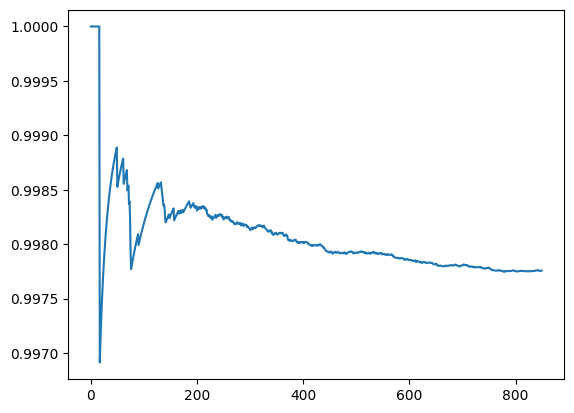

In [84]:
l=simu(850)
plt.plot(l)

Al hacer la simulación del experimento varias veces, nos dimos cuenta que empieza a estabilizarse alrededor de las $850$ y es de interés saber la media de esto:

In [85]:
np.mean(l)

np.float64(0.9980676071326892)

Finalmente se ve que la solución por simulación tiende a la solución analítica.